In [1]:
!mamba install pandas numpy matplotlib seaborn scikit-learn
import pandas as pd
import seaborn as sns

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 1.242699999988079 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ brotli-python                 1.2.0                         py313h33caa6c_0               emscripten-forge              
+ certifi                       2026.4.22                     pyhd8ed1ab_0                  conda-forge                   
+ charset-normalizer            3.4.7                         pyhd8ed1ab_0                  conda-forge                   
+ idna                          3.13                          pyhcf101f3_0                  conda-forge                   
+ joblib                     

In [5]:
df= pd.read_csv('NYPD_Arrest_Data_(Year_to_Date)_20260504.csv')

In [7]:
df.head()

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
0,318451126,01/06/2026,105.0,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,Q,110,0,25-44,M,BLACK,1020232,210719,40.744989,-73.870145,POINT (-73.870145 40.744989)
1,318308486,01/03/2026,203.0,"TRESPASS 3, CRIMINAL",352.0,CRIMINAL TRESPASS,PL 140100G,M,K,77,1,25-44,M,BLACK,1003358,182945,40.668798,-73.931120,POINT (-73.93112014 40.66879784)
2,318550123,01/08/2026,105.0,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,B,48,0,25-44,M,WHITE HISPANIC,1011780,246837,40.844152,-73.900500,POINT (-73.9005 40.844152)
3,318580867,01/07/2026,397.0,"ROBBERY,OPEN AREA UNCLASSIFIED",105.0,ROBBERY,PL 160102B,F,M,28,0,(null),(null),BLACK,999788,233328,40.807102,-73.943874,POINT (-73.943874 40.807102)
4,318684449,01/10/2026,397.0,"ROBBERY,OPEN AREA UNCLASSIFIED",105.0,ROBBERY,PL 160102A,F,B,45,0,<18,F,BLACK,1031351,254245,40.864401,-73.829711,POINT (-73.829711 40.864401)


In [4]:
df.shape

(69305, 19)

In [8]:
df.columns

Index(['ARREST_KEY', 'ARREST_DATE', 'PD_CD', 'PD_DESC', 'KY_CD', 'OFNS_DESC',
       'LAW_CODE', 'LAW_CAT_CD', 'ARREST_BORO', 'ARREST_PRECINCT',
       'JURISDICTION_CODE', 'AGE_GROUP', 'PERP_SEX', 'PERP_RACE', 'X_COORD_CD',
       'Y_COORD_CD', 'Latitude', 'Longitude', 'Location'],
      dtype='str')

In [9]:
#Arrests by Borough
Borough = df.groupby(['ARREST_BORO']).size().sort_values(ascending = False)
print(Borough)

ARREST_BORO
K    21111
M    15870
B    15613
Q    14160
S     2551
dtype: int64


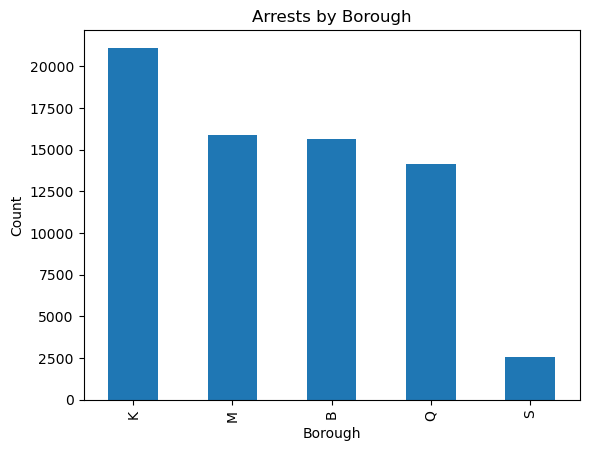

In [10]:
Borough.plot(kind='bar')

import matplotlib.pyplot as plt
plt.title("Arrests by Borough")
plt.xlabel("Borough")
plt.ylabel("Count")
plt.show()

In [11]:
#Arrests By Race
Race = df.groupby(['PERP_RACE']).size().sort_values(ascending = False)
print(Race)

PERP_RACE
BLACK                             33340
WHITE HISPANIC                    17665
WHITE                              7175
BLACK HISPANIC                     6651
ASIAN / PACIFIC ISLANDER           4096
AMERICAN INDIAN/ALASKAN NATIVE      204
UNKNOWN                             174
dtype: int64


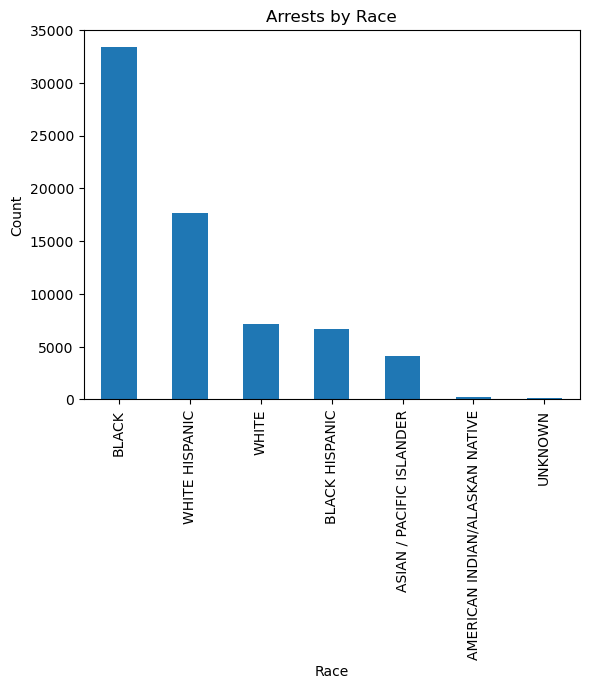

In [12]:
Race.plot(kind='bar')

import matplotlib.pyplot as plt
plt.title("Arrests by Race")
plt.xlabel("Race")
plt.ylabel("Count")
plt.show()

In [14]:
#Types of Offenses
Crime = df.groupby(['OFNS_DESC']).size().sort_values(ascending = False)
print(Crime)

OFNS_DESC
ASSAULT 3 & RELATED OFFENSES        9415
PETIT LARCENY                       6478
DANGEROUS DRUGS                     5726
FELONY ASSAULT                      5462
VEHICLE AND TRAFFIC LAWS            4776
MISCELLANEOUS PENAL LAW             4627
OTHER OFFENSES RELATED TO THEFT     4019
CRIMINAL MISCHIEF & RELATED OF      2929
OFFENSES AGAINST PUBLIC ADMINI      2679
ROBBERY                             2593
DANGEROUS WEAPONS                   2433
GRAND LARCENY                       2428
OTHER STATE LAWS                    2166
BURGLARY                            1690
SEX CRIMES                          1637
OFF. AGNST PUB ORD SENSBLTY &       1360
FORGERY                             1082
CRIMINAL TRESPASS                   1048
POSSESSION OF STOLEN PROPERTY        876
OTHER TRAFFIC INFRACTION             817
OFFENSES INVOLVING FRAUD             717
INTOXICATED & IMPAIRED DRIVING       699
FRAUDS                               452
MURDER & NON-NEGL. MANSLAUGHTE       423
OFFENS

In [23]:
#Drop rows with Null Offense Description
df = df[~df['OFNS_DESC'].isin(['(null)', 'Nan', '', ' '])]

In [27]:
#Offenses by Race 
pivot = df.groupby(['PERP_RACE', 'OFNS_DESC']).size().unstack(fill_value=0)
print(pivot)

OFNS_DESC                       ADMINISTRATIVE CODE  ADMINISTRATIVE CODES  \
PERP_RACE                                                                   
AMERICAN INDIAN/ALASKAN NATIVE                    0                     0   
ASIAN / PACIFIC ISLANDER                          9                     0   
BLACK                                            17                     1   
BLACK HISPANIC                                    5                     0   
UNKNOWN                                           0                     0   
WHITE                                             2                     0   
WHITE HISPANIC                                    7                     0   

OFNS_DESC                       ALCOHOLIC BEVERAGE CONTROL LAW  \
PERP_RACE                                                        
AMERICAN INDIAN/ALASKAN NATIVE                               0   
ASIAN / PACIFIC ISLANDER                                    13   
BLACK                                     

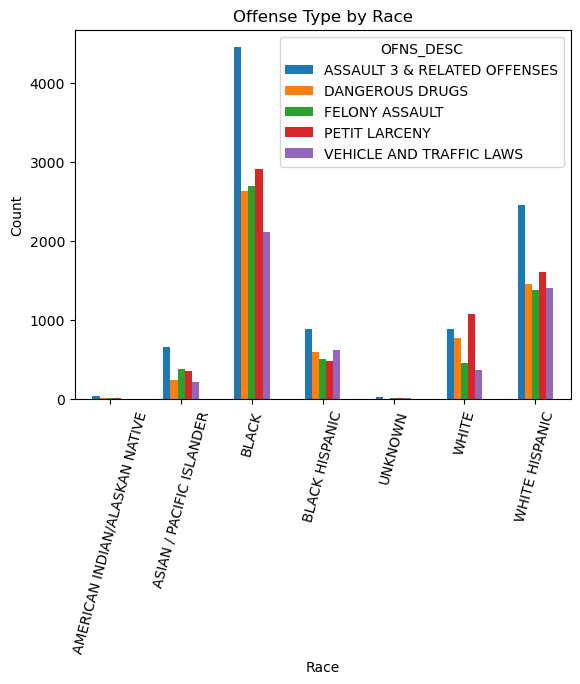

In [30]:
top_offenses = df['OFNS_DESC'].value_counts().head(5).index
filtered = df[df['OFNS_DESC'].isin(top_offenses)]

grouped = filtered.groupby(['PERP_RACE', 'OFNS_DESC']).size().unstack()

grouped.plot(kind='bar')

import matplotlib.pyplot as plt
plt.title("Offense Type by Race")
plt.xlabel("Race")
plt.ylabel("Count")
plt.xticks(rotation=75)
plt.show()

In [19]:
#Arrests by Race and Borough 
df.groupby(['ARREST_BORO', 'PERP_RACE']).size()

ARREST_BORO  PERP_RACE                     
B            AMERICAN INDIAN/ALASKAN NATIVE       31
             ASIAN / PACIFIC ISLANDER            209
             BLACK                              7305
             BLACK HISPANIC                     2830
             UNKNOWN                              50
             WHITE                               549
             WHITE HISPANIC                     4639
K            AMERICAN INDIAN/ALASKAN NATIVE       51
             ASIAN / PACIFIC ISLANDER           1164
             BLACK                             12102
             BLACK HISPANIC                     1193
             UNKNOWN                              32
             WHITE                              2473
             WHITE HISPANIC                     4096
M            AMERICAN INDIAN/ALASKAN NATIVE       51
             ASIAN / PACIFIC ISLANDER            627
             BLACK                              7734
             BLACK HISPANIC                     1774
  

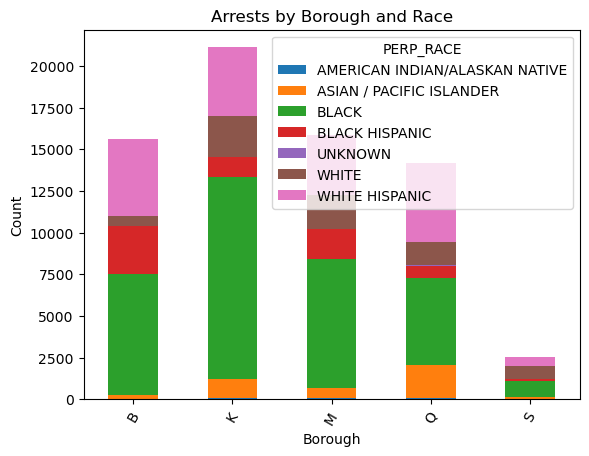

In [21]:
grouped = df.groupby(['ARREST_BORO', 'PERP_RACE']).size().unstack()

grouped.plot(kind='bar', stacked=True)

import matplotlib.pyplot as plt
plt.title("Arrests by Borough and Race")
plt.xlabel("Borough")
plt.ylabel("Count")
plt.xticks(rotation=60)
plt.show()

In [ ]:
Conclusion: The data shows that a highest number of arrests occurred in Brooklyn. Additionally, Black individuals represent a larger proportion of arrests in the dataset. 
    These patterns may be influenced by factors such as population size, policing practices, and reporting differences. 